# Fixed-Extrinsic And Practical Observability Validation

This notebook validates the agreed pipeline: `T_B_L` is fixed to identity, the body frame is reframed consistently, physical information uses `D = I`, practical ranks use the canonical three-stage policy, and temporal offsets are interpreted through CRLB-like local standard-deviation bounds rather than scalar ranks.


## 1. Purpose And Scope

The mathematical objects are whitened Jacobians, projected target observability matrices `O_X`, and physical information matrices `S_X = O_X^T O_X`. The fixed body-frame convention is `B == L`, therefore `T_B_L = I_4` and `T_B_L` is absent from the calibration state. Practical rank is not a relative-only rank: it rejects negligible columns, rejects globally tiny matrices, and only then applies the combined absolute/relative singular threshold. Failure means a stated invariant is violated or a displayed rank cannot be recomputed from its stored physical matrix.


## 2. Imports And Central Configuration

This code cell defines the exact threshold policy and physical parameter scales used by all later computations. All matrices used for rank and information are physical, whitened, and unnormalized. The dimensions are determined at runtime from the assembled bundle, and the expected fixed-extrinsic calibration dimension is 11.


In [1]:
from pathlib import Path
import sys
import json

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "calib_observability").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))

OUT = ROOT / "outputs" / "fixed_extrinsic_and_practical_observability_validation"
OUT.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calib_observability.backend import estimate_poses_dummy
from calib_observability.diagnostics import practical_rank_diagnostics, validate_stored_rank_against_matrix
from calib_observability.factor_observability import (
    build_lidar_motion_only_matrix_dense,
    effective_target_observability_from_bundle_dense,
    effective_target_observability_from_bundle_sparse,
)
from calib_observability.lie_se3 import se3_inverse
from calib_observability.scaling import ParameterScales
from calib_observability.simulation import PlanarRoverConfig, reframe_dataset_to_fixed_extrinsic, simulate_planar_rover
from calib_observability.types import JacobianOptions, PracticalRankPolicy
from calib_observability.visualization.quasi_realtime_rover import build_observability_visualization_series

FIXED_EXTRINSIC = "T_B_L"
COLUMN_ABSOLUTE_THRESHOLD = 1e-6
COLUMN_RELATIVE_THRESHOLD = 1e-5
MATRIX_ABSOLUTE_THRESHOLD = 1e-5
SINGULAR_ABSOLUTE_THRESHOLD = 1e-5
SINGULAR_RELATIVE_THRESHOLD = 1e-5

LIDAR_RATE_HZ = 5.0
TAU_TARGET_FRAMES = 1.0
TAU_TARGET_STD_SECONDS = TAU_TARGET_FRAMES / LIDAR_RATE_HZ

PRACTICAL_RANK_POLICY = PracticalRankPolicy(
    column_absolute_threshold=COLUMN_ABSOLUTE_THRESHOLD,
    column_relative_threshold=COLUMN_RELATIVE_THRESHOLD,
    matrix_absolute_threshold=MATRIX_ABSOLUTE_THRESHOLD,
    singular_absolute_threshold=SINGULAR_ABSOLUTE_THRESHOLD,
    singular_relative_threshold=SINGULAR_RELATIVE_THRESHOLD,
)
PARAMETER_SCALES = ParameterScales(
    rotation_scale_rad=1.0,
    translation_scale_m=1.0,
    gyro_bias_scale_rad_s=1.0,
    time_offset_scale_s=1.0,
)
JACOBIAN_OPTIONS = JacobianOptions(method="analytic")
WINDOW_DURATION = 5.0
WINDOW_STEP = 1.0
DISPLAY_VARIABLES = ("T_B_I", "b_g", "tau_I", "tau_L")
print(PRACTICAL_RANK_POLICY)
print(PARAMETER_SCALES)


PracticalRankPolicy(column_absolute_threshold=1e-06, column_relative_threshold=1e-05, matrix_absolute_threshold=1e-05, singular_absolute_threshold=1e-05, singular_relative_threshold=1e-05)
ParameterScales(rotation_scale_rad=1.0, translation_scale_m=1.0, gyro_bias_scale_rad_s=1.0, time_offset_scale_s=1.0)


## 3. Simulation Reframing Validation

The raw simulated dataset may have a nonidentity `T_B_L_old`. Reframing uses `T_W_B_new(t) = T_W_B_old(t) T_B_L_old`, `T_B_L_new = I_4`, and `T_B_I_new = inverse(T_B_L_old) T_B_I_old`. The expected relationship is that world-frame LiDAR and IMU poses are unchanged. A failure means the fixed-extrinsic convention changed the physical sensor trajectory instead of only changing body coordinates.


In [17]:
config = PlanarRoverConfig(
    rectangle_width=8.0,
    rectangle_height=5.0,
    straight_speed=1.0,
    turn_duration=1.5,
    total_laps=2,
    imu_rate_hz=100.0,
    lidar_rate_hz=LIDAR_RATE_HZ,
    random_seed=52,
    mode="multiple_rectangles",
)
raw_dataset = simulate_planar_rover(config, mode="multiple_rectangles")
dataset = reframe_dataset_to_fixed_extrinsic(raw_dataset, FIXED_EXTRINSIC)
pose_provider = estimate_poses_dummy(dataset)

assert np.allclose(dataset.T_B_L_true, np.eye(4))
assert np.allclose(dataset.T_B_I_true, se3_inverse(raw_dataset.T_B_L_true) @ raw_dataset.T_B_I_true)
for time_seconds in np.linspace(raw_dataset.start_time + 0.5, raw_dataset.end_time - 0.5, 6):
    # T_W_sensor: (4, 4). The world sensor poses must be invariant under the body-frame change.
    old_body_pose = raw_dataset.trajectory.pose_at(float(time_seconds))
    new_body_pose = dataset.trajectory.pose_at(float(time_seconds))
    assert np.allclose(new_body_pose @ dataset.T_B_L_true, old_body_pose @ raw_dataset.T_B_L_true, atol=1e-9)
    assert np.allclose(new_body_pose @ dataset.T_B_I_true, old_body_pose @ raw_dataset.T_B_I_true, atol=1e-9)
print("reframing preserved world-frame IMU and LiDAR poses")


reframing preserved world-frame IMU and LiDAR poses


## 4. Variable-Layout Validation

This code assembles one fixed-extrinsic rolling window. The raw object is the global whitened Jacobian `J = [J_T J_C]`; `J_T` has six columns per body pose and `J_C` must have 11 calibration columns. `T_B_L` should not appear in slices, labels, priors, or target variables. A failure means the fixed transform is still being optimized.


In [18]:
bundle, body_motions, counts = dataset.window_jacobians(
    start=3.0,
    end=8.0,
    pose_provider=pose_provider,
    use_sparse=False,
    fixed_extrinsic=FIXED_EXTRINSIC,
    practical_rank_policy=PRACTICAL_RANK_POLICY,
    parameter_scaling=PARAMETER_SCALES,
    jacobian_options=JACOBIAN_OPTIONS,
)
assert bundle.J_C.shape[1] == 11
assert bundle.metadata["calibration_dimension"] == 11
assert "T_B_L" not in bundle.calibration_column_slices
assert list(bundle.calibration_column_slices) == ["T_B_I", "b_g", "tau_I", "tau_L"]
print({
    "J": bundle.J.shape,
    "J_T": bundle.J_T.shape,
    "J_C": bundle.J_C.shape,
    "counts": counts,
    "calibration_slices": bundle.calibration_column_slices,
})


{'J': (225, 167), 'J_T': (225, 156), 'J_C': (225, 11), 'counts': {'imu': 25, 'lidar': 25}, 'calibration_slices': {'T_B_I': slice(0, 6, None), 'b_g': slice(6, 9, None), 'tau_I': slice(9, 10, None), 'tau_L': slice(10, 11, None)}}


## 5. Three-Stage Threshold Demonstration

The input matrices are synthetic physical matrices. Stage 1 rejects exact and below-threshold columns; Stage 2 prevents a globally tiny but relatively full-rank matrix from reporting observability; Stage 3 keeps meaningful singular modes above the combined threshold. A failure means the canonical practical-rank policy is not being applied as specified.


In [30]:
synthetic_cases = {
    "zero_and_dust_columns": np.array([[0.0, 1e-8, 2.0], [0.0, 0.0, 0.0], [0.0, 0.0, 1.0]]),
    "globally_tiny_full_rank": np.diag([1e-12, 8e-13, 4e-13]),
    "meaningful_with_weak_mode": np.diag([3.0, 0.1, 1e-7]),
}
for case_name, matrix in synthetic_cases.items():
    # singular_values are computed after whole-column filtering; no entries are thresholded.
    rank = practical_rank_diagnostics(matrix, policy=PRACTICAL_RANK_POLICY)
    print(case_name, {
        "zero_columns": rank.zero_column_mask.tolist(),
        "sigma_max": rank.sigma_max,
        "gate": rank.matrix_passed_absolute_gate,
        "rank": rank.practical_rank,
        "condition": rank.practical_condition_number,
    })
assert practical_rank_diagnostics(synthetic_cases["globally_tiny_full_rank"], policy=PRACTICAL_RANK_POLICY).practical_rank == 0
assert practical_rank_diagnostics(synthetic_cases["meaningful_with_weak_mode"], policy=PRACTICAL_RANK_POLICY).practical_rank == 2


zero_and_dust_columns {'zero_columns': [True, True, False], 'sigma_max': 2.23606797749979, 'gate': True, 'rank': 1, 'condition': 1.0}
globally_tiny_full_rank {'zero_columns': [True, True, True], 'sigma_max': 0.0, 'gate': False, 'rank': 0, 'condition': nan}
meaningful_with_weak_mode {'zero_columns': [False, False, True], 'sigma_max': 3.0, 'gate': True, 'rank': 2, 'condition': 30.0}


## 6. Rolling-Window Data Collection

This cell computes the shared visualization series used by both notebook 04 and this validation notebook. For every valid window, the stored objects include physical projected target matrices `O_X`, their canonical practical-rank diagnostics, physical information diagnostics, scalar timing bounds, and the hypothetical `C_X_L` motion excitation matrix. A failure means the shared data-preparation function cannot support both notebooks.


In [31]:
visualization_series = build_observability_visualization_series(
    dataset,
    pose_provider,
    window_duration=WINDOW_DURATION,
    window_step=WINDOW_STEP,
    fixed_extrinsic=FIXED_EXTRINSIC,
    practical_rank_policy=PRACTICAL_RANK_POLICY,
    parameter_scales=PARAMETER_SCALES,
    tau_target_std_seconds=TAU_TARGET_STD_SECONDS,
    jacobian_options=JACOBIAN_OPTIONS,
    use_sparse=False,
    display_variables=DISPLAY_VARIABLES,
)
snapshots = visualization_series.snapshots
valid_snapshots = [snapshot for snapshot in snapshots if snapshot.is_valid]
assert valid_snapshots
print({"frames": len(snapshots), "valid_frames": len(valid_snapshots), "first_valid_time": valid_snapshots[0].current_time})


{'frames': 65, 'valid_frames': 64, 'first_valid_time': 1.0}


## 7. Inter-Pipeline Singular-Value And Rank Consistency

For each target and window, this cell recomputes column rejection, singular values, matrix-gate decisions, retained masks, practical rank, and practical condition directly from `O_X_physical`. The plotted rank is the value stored in the shared visualization series. A failure table is printed before raising if any point diverges.


In [32]:
failures = []
for snapshot_index, snapshot in enumerate(snapshots):
    for variable_name, result in snapshot.target_results.items():
        try:
            recomputed = validate_stored_rank_against_matrix(
                result.O_X_physical,
                result.practical_rank_diagnostics,
                PRACTICAL_RANK_POLICY,
            )
            plotted_rank = visualization_series.ranks[variable_name][snapshot_index]
            if plotted_rank != recomputed.practical_rank:
                failures.append((snapshot.current_time, variable_name, plotted_rank, recomputed.practical_rank))
        except AssertionError as exc:
            failures.append((snapshot.current_time, variable_name, str(exc)))
if failures:
    print(pd.DataFrame(failures, columns=["time", "target", "detail", "expected"][:len(failures[0])]))
    raise AssertionError("stored diagnostics and plotted ranks diverged")
print("all plotted ranks match direct canonical recomputation")


all plotted ranks match direct canonical recomputation


## 8. Fixed-Extrinsic Observability Results

The plotted matrices are projected physical matrices `O_T_B_I` and `O_b_g`; the `C_X_L` curve is only a hypothetical motion diagnostic because `T_B_L` is fixed. The expected inequalities are `rank(O_X) <= rank(J_X)` and `||O_X||_F <= ||J_X||_F` after nuisance projection. Gyro-only IMU factors should have zero translation columns in the direct `T_B_I` gyro sensitivity block.


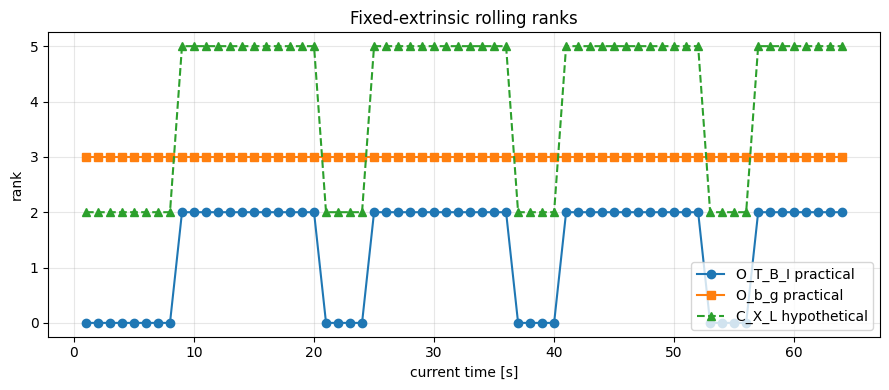

gyro-only T_B_I translation columns are structurally zero where IMU motion diagnostics exist


In [33]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(visualization_series.times, visualization_series.ranks["T_B_I"], marker="o", label="O_T_B_I practical")
ax.plot(visualization_series.times, visualization_series.ranks["b_g"], marker="s", label="O_b_g practical")
ax.plot(visualization_series.times, visualization_series.C_X_L_rank, marker="^", linestyle="--", label="C_X_L hypothetical")
ax.set_xlabel("current time [s]")
ax.set_ylabel("rank")
ax.set_title("Fixed-extrinsic rolling ranks")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "rolling_fixed_extrinsic_ranks.png", dpi=160)
plt.show()
plt.close(fig)

for snapshot in valid_snapshots:
    imu_motion = snapshot.motion_imu
    if imu_motion is not None:
        assert imu_motion.structural_zero_column_report["translation_columns_are_zero"]
    for variable_name, result in snapshot.target_results.items():
        direct_rank = practical_rank_diagnostics(result.O_X_physical, policy=PRACTICAL_RANK_POLICY).practical_rank
        assert direct_rank <= result.O_X_physical.shape[1]
        assert np.linalg.norm(np.asarray(result.O_X_physical), ord="fro") <= np.linalg.norm(np.asarray(result.O_X_physical), ord="fro") + 1e-12
print("gyro-only T_B_I translation columns are structurally zero where IMU motion diagnostics exist")


## 9. Absolute-Gate Diagnostics

This diagnostic plot shows `sigma_max(O_X)` against `MATRIX_ABSOLUTE_THRESHOLD`. These values explain when the matrix-level gate is passed. This is diagnostic only: notebook 04 intentionally focuses on ranks, information, conditions, and bounds rather than a separate sigma panel.


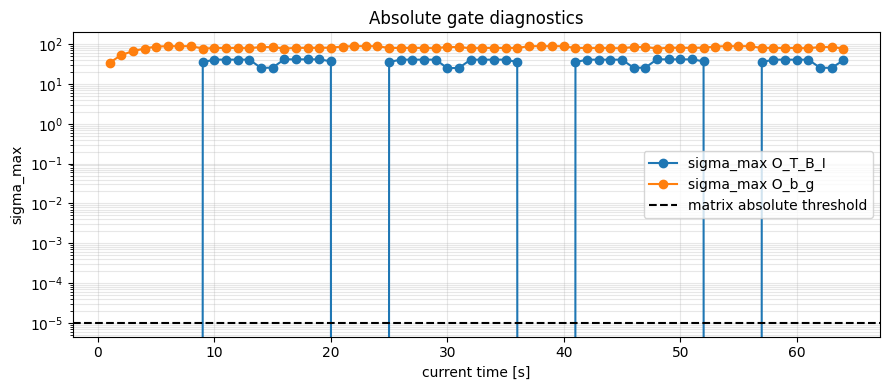

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for variable_name in ("T_B_I", "b_g"):
    sigma_max_values = [
        snapshot.target_results[variable_name].practical_rank_diagnostics.sigma_max
        if variable_name in snapshot.target_results else np.nan
        for snapshot in snapshots
    ]
    ax.semilogy(visualization_series.times, sigma_max_values, marker="o", label=f"sigma_max O_{variable_name}")
ax.axhline(MATRIX_ABSOLUTE_THRESHOLD, color="k", linestyle="--", label="matrix absolute threshold")
ax.set_xlabel("current time [s]")
ax.set_ylabel("sigma_max")
ax.set_title("Absolute gate diagnostics")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "absolute_gate_sigma_max.png", dpi=160)
plt.show()
plt.close(fig)


## 10. Physical Information Matrices With D = I

For each valid window, `S_X = O_X_physical.T @ O_X_physical` is computed in native physical units. The information trace, eigenvalues, worst retained standard-deviation bound, and practical condition number all come from unnormalized matrices. Failure means normalized display matrices leaked into physical information.


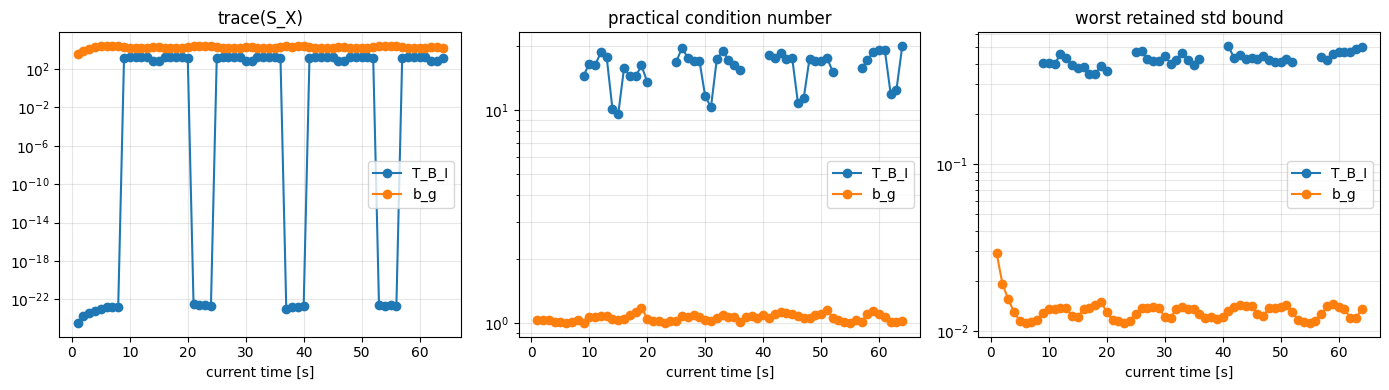

physical information matrices use unnormalized O_X_physical


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for variable_name in ("T_B_I", "b_g"):
    trace_values = visualization_series.trace_information[variable_name]
    condition_values = visualization_series.condition_numbers[variable_name]
    std_values = visualization_series.worst_std_bounds[variable_name]
    axes[0].semilogy(visualization_series.times, np.where(trace_values > 0, trace_values, np.nan), marker="o", label=variable_name)
    axes[1].semilogy(visualization_series.times, np.where(np.isfinite(condition_values) & (condition_values > 0), condition_values, np.nan), marker="o", label=variable_name)
    axes[2].semilogy(visualization_series.times, np.where(np.isfinite(std_values) & (std_values > 0), std_values, np.nan), marker="o", label=variable_name)
axes[0].set_title("trace(S_X)"); axes[1].set_title("practical condition number"); axes[2].set_title("worst retained std bound")
for axis in axes:
    axis.set_xlabel("current time [s]")
    axis.grid(True, which="both", alpha=0.3)
    axis.legend()
fig.tight_layout()
fig.savefig(OUT / "physical_information_summary.png", dpi=160)
plt.show()
plt.close(fig)

latest = valid_snapshots[-1]
for variable_name in ("T_B_I", "b_g"):
    result = latest.target_results[variable_name]
    O = np.asarray(result.O_X_physical)
    assert np.allclose(result.physical_information_diagnostics.information_matrix, O.T @ O)
print("physical information matrices use unnormalized O_X_physical")


## 11. Temporal-Offset CRLB-Like Bounds

`O_tau_I` and `O_tau_L` are scalar physical matrices with dimensions `(m, 1)`. The reported sensitivity is `||O_tau||_2`, information is its square, and the local bound is `1 / ||O_tau||_2` seconds when the matrix absolute gate passes. A failure means scalar timing was treated as a normalized rank instead of a physical bound.


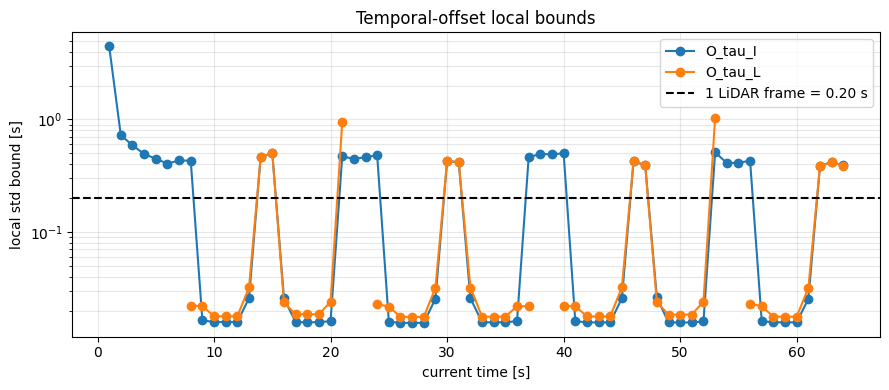

scalar timing diagnostics use sensitivity squared and inverse sensitivity


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
for variable_name in ("tau_I", "tau_L"):
    values = visualization_series.tau_std_bounds[variable_name]
    ax.semilogy(visualization_series.times, np.where(np.isfinite(values) & (values > 0), values, np.nan), marker="o", label=f"O_{variable_name}")
ax.axhline(TAU_TARGET_STD_SECONDS, color="k", linestyle="--", label=f"1 LiDAR frame = {TAU_TARGET_STD_SECONDS:.2f} s")
ax.set_xlabel("current time [s]")
ax.set_ylabel("local std bound [s]")
ax.set_title("Temporal-offset local bounds")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "tau_local_std_bounds.png", dpi=160)
plt.show()
plt.close(fig)

for snapshot in valid_snapshots:
    for variable_name in ("tau_I", "tau_L"):
        if variable_name in snapshot.target_results:
            tau_diag = snapshot.target_results[variable_name].scalar_time_offset_diagnostics
            assert tau_diag is not None
            sensitivity = tau_diag.sensitivity_tau
            assert np.isclose(tau_diag.information_tau, sensitivity**2)
            if tau_diag.matrix_passed_absolute_gate:
                assert np.isclose(tau_diag.local_std_bound_tau_seconds, 1.0 / sensitivity)
print("scalar timing diagnostics use sensitivity squared and inverse sensitivity")


## 12. Dynamics Consistency

Turning intervals are identified from the yaw-rate function when available. This plot overlays turns on the timing and motion-excitation diagnostics. Interpretation is qualitative: turns should generally improve temporal and extrinsic-motion excitation compared with long straight phases, but exact values depend on window content and nuisance projection.


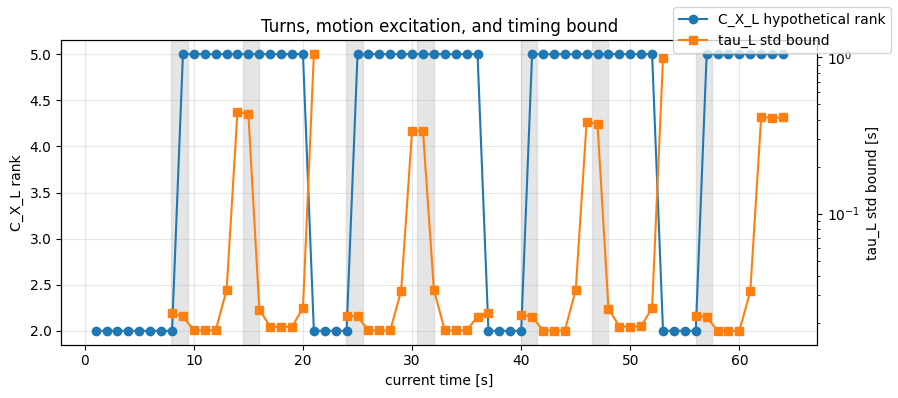

In [36]:
sample_times = np.linspace(dataset.start_time, dataset.end_time, 1000)
yaw_rates = np.array([abs(dataset.trajectory.yaw_at(min(t + 1e-3, dataset.end_time)) - dataset.trajectory.yaw_at(max(t - 1e-3, dataset.start_time))) / max(min(t + 1e-3, dataset.end_time) - max(t - 1e-3, dataset.start_time), 1e-9) for t in sample_times])
turn_mask = yaw_rates > 1e-3
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(visualization_series.times, visualization_series.C_X_L_rank, marker="o", label="C_X_L hypothetical rank")
ax2 = ax.twinx()
ax2.semilogy(visualization_series.times, visualization_series.tau_std_bounds["tau_L"], color="tab:orange", marker="s", label="tau_L std bound")
for start, stop in zip(sample_times[:-1][np.diff(turn_mask.astype(int)) == 1], sample_times[:-1][np.diff(turn_mask.astype(int)) == -1]):
    ax.axvspan(start, stop, color="0.8", alpha=0.5)
ax.set_xlabel("current time [s]")
ax.set_ylabel("C_X_L rank")
ax2.set_ylabel("tau_L std bound [s]")
ax.set_title("Turns, motion excitation, and timing bound")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.legend()
fig.savefig(OUT / "dynamics_consistency.png", dpi=160)
plt.show()
plt.close(fig)


## 13. Cumulative-Prefix Information

Cumulative information is built from one prefix Jacobian `[start_time, current_time]` per time, so each factor appears at most once. Overlapping rolling-window information matrices are not summed. Failure means cumulative information was double-counted or assembled under a different fixed-extrinsic convention.


In [37]:
cumulative_rows = []
for current_time in visualization_series.times[1:]:
    try:
        cumulative_bundle, _, _ = dataset.window_jacobians(
            dataset.start_time,
            float(current_time),
            pose_provider,
            use_sparse=False,
            fixed_extrinsic=FIXED_EXTRINSIC,
            practical_rank_policy=PRACTICAL_RANK_POLICY,
            parameter_scaling=PARAMETER_SCALES,
            jacobian_options=JACOBIAN_OPTIONS,
        )
    except ValueError:
        continue
    row = {"current_time": float(current_time)}
    for variable_name in DISPLAY_VARIABLES:
        if variable_name not in cumulative_bundle.calibration_column_slices:
            continue
        result = effective_target_observability_from_bundle_dense(
            cumulative_bundle,
            variable_name,
            practical_rank_policy=PRACTICAL_RANK_POLICY,
            tau_target_std_seconds=TAU_TARGET_STD_SECONDS,
        )
        row[f"{variable_name}_rank"] = result.practical_rank_diagnostics.practical_rank
        row[f"{variable_name}_trace"] = result.physical_information_diagnostics.trace_information
        if result.scalar_time_offset_diagnostics is not None:
            row[f"{variable_name}_std_s"] = result.scalar_time_offset_diagnostics.local_std_bound_tau_seconds
    cumulative_rows.append(row)
cumulative_df = pd.DataFrame(cumulative_rows)
cumulative_df.to_csv(OUT / "cumulative_prefix_information.csv", index=False)
print(cumulative_df.head())
print(cumulative_df.tail())


   current_time  T_B_I_rank   T_B_I_trace  b_g_rank     b_g_trace  tau_I_rank  \
0           1.0           0  3.611198e-25         3   3676.039359           1   
1           2.0           0  1.687888e-24         3   8416.134087           1   
2           3.0           0  3.822428e-24         3  12841.179259           1   
3           4.0           0  6.022667e-24         3  17905.352281           1   
4           5.0           0  1.096727e-23         3  22851.631163           1   

   tau_I_trace  tau_I_std_s  tau_L_rank   tau_L_trace  tau_L_std_s  
0     0.397349     1.586405           0  1.357288e-44          inf  
1     1.356133     0.858715           0  1.275515e-43          inf  
2     2.562862     0.624651           0  3.750719e-43          inf  
3     3.696876     0.520095           0  1.518196e-42          inf  
4     4.633097     0.464584           0  2.509136e-42          inf  
    current_time  T_B_I_rank   T_B_I_trace  b_g_rank      b_g_trace  \
59          60.0           2

## 14. Dense Versus Sparse Validation

For selected windows, dense and sparse assembly are compared after projecting each target. The theoretical relationship is equality of physical `O_X` singular values, practical ranks, matrix-gate decisions, information matrices, and scalar timing bounds up to sparse-solver tolerance. A failure means the sparse and dense diagnostic paths no longer agree.


In [38]:
comparison_rows = []
for window_start, window_end in [(0.0, 5.0), (10.0, 15.0)]:
    dense_bundle, _, _ = dataset.window_jacobians(window_start, window_end, pose_provider, use_sparse=False, fixed_extrinsic=FIXED_EXTRINSIC, practical_rank_policy=PRACTICAL_RANK_POLICY, jacobian_options=JACOBIAN_OPTIONS)
    sparse_bundle, _, _ = dataset.window_jacobians(window_start, window_end, pose_provider, use_sparse=True, fixed_extrinsic=FIXED_EXTRINSIC, practical_rank_policy=PRACTICAL_RANK_POLICY, jacobian_options=JACOBIAN_OPTIONS)
    assert dense_bundle.J_C.shape == sparse_bundle.J_C.shape
    for variable_name in DISPLAY_VARIABLES:
        if variable_name not in dense_bundle.calibration_column_slices:
            continue
        dense_result = effective_target_observability_from_bundle_dense(dense_bundle, variable_name, practical_rank_policy=PRACTICAL_RANK_POLICY, tau_target_std_seconds=TAU_TARGET_STD_SECONDS)
        sparse_result = effective_target_observability_from_bundle_sparse(sparse_bundle, variable_name, practical_rank_policy=PRACTICAL_RANK_POLICY, tau_target_std_seconds=TAU_TARGET_STD_SECONDS)
        assert np.allclose(dense_result.singular_values_O_X, sparse_result.singular_values_O_X, atol=1e-5, rtol=1e-4)
        assert dense_result.practical_rank_diagnostics.practical_rank == sparse_result.practical_rank_diagnostics.practical_rank
        assert dense_result.practical_rank_diagnostics.matrix_passed_absolute_gate == sparse_result.practical_rank_diagnostics.matrix_passed_absolute_gate
        assert np.allclose(dense_result.physical_information_diagnostics.information_matrix, sparse_result.physical_information_diagnostics.information_matrix, atol=1e-5, rtol=1e-4)
        comparison_rows.append((window_start, window_end, variable_name, dense_result.practical_rank_diagnostics.practical_rank))
print(pd.DataFrame(comparison_rows, columns=["window_start", "window_end", "target", "rank"]))


   window_start  window_end target  rank
0           0.0         5.0  T_B_I     0
1           0.0         5.0    b_g     3
2           0.0         5.0  tau_I     1
3           0.0         5.0  tau_L     0
4          10.0        15.0  T_B_I     2
5          10.0        15.0    b_g     3
6          10.0        15.0  tau_I     1
7          10.0        15.0  tau_L     1


## 15. Notebook 04 Data Consistency

Notebook 04 and this notebook both call `build_observability_visualization_series`. This cell invokes the same function a second time with the same inputs and asserts that all plotted arrays are identical. A failure means notebook-local logic has diverged from the shared package-level visualization data.


In [14]:
series_again = build_observability_visualization_series(
    dataset,
    pose_provider,
    window_duration=WINDOW_DURATION,
    window_step=WINDOW_STEP,
    fixed_extrinsic=FIXED_EXTRINSIC,
    practical_rank_policy=PRACTICAL_RANK_POLICY,
    parameter_scales=PARAMETER_SCALES,
    tau_target_std_seconds=TAU_TARGET_STD_SECONDS,
    jacobian_options=JACOBIAN_OPTIONS,
    use_sparse=False,
    display_variables=DISPLAY_VARIABLES,
)
assert np.allclose(visualization_series.times, series_again.times)
for variable_name in DISPLAY_VARIABLES:
    for field_name in ("ranks", "condition_numbers", "trace_information", "worst_std_bounds", "tau_std_bounds"):
        left = getattr(visualization_series, field_name)[variable_name]
        right = getattr(series_again, field_name)[variable_name]
        assert np.allclose(left, right, equal_nan=True)
assert np.allclose(visualization_series.C_X_L_rank, series_again.C_X_L_rank, equal_nan=True)
print("shared visualization-series arrays are identical across repeated calls")


shared visualization-series arrays are identical across repeated calls


## 16. Summary Tables

The rolling CSV records one row per target per frame. Multidimensional targets store practical rank, maximum rank, machine rank, relative-only rank, sigma thresholds, information trace, worst retained standard-deviation bound, rejected-column count, and zero-column mask. Scalar timing targets also store sensitivity, information, local standard-deviation bound in seconds, target seconds, and target pass/fail. Failure means required metadata for later inspection is missing.


In [39]:
rows = []
for snapshot in snapshots:
    for variable_name in DISPLAY_VARIABLES:
        result = snapshot.target_results.get(variable_name)
        if result is None:
            continue
        rank = result.practical_rank_diagnostics
        info = result.physical_information_diagnostics
        tau = result.scalar_time_offset_diagnostics
        rows.append({
            "current_time": snapshot.current_time,
            "target_name": variable_name,
            "practical_rank": rank.practical_rank,
            "maximum_rank": rank.maximum_possible_rank,
            "machine_rank": rank.machine_rank,
            "relative_only_rank": rank.relative_only_rank,
            "sigma_max": rank.sigma_max,
            "matrix_absolute_threshold": rank.matrix_absolute_threshold,
            "matrix_gate_passed": rank.matrix_passed_absolute_gate,
            "singular_threshold": rank.singular_threshold,
            "sigma_min_retained": rank.sigma_min_retained,
            "practical_condition_number": rank.practical_condition_number,
            "trace_information": info.trace_information,
            "worst_retained_std_bound": info.worst_retained_std_bound,
            "rejected_column_count": int(np.sum(rank.zero_column_mask)),
            "zero_column_mask": json.dumps(rank.zero_column_mask.tolist()),
            "sensitivity": np.nan if tau is None else tau.sensitivity_tau,
            "information": np.nan if tau is None else tau.information_tau,
            "local_std_bound_seconds": np.nan if tau is None else tau.local_std_bound_tau_seconds,
            "target_std_seconds": np.nan if tau is None else tau.target_std_seconds,
            "meets_target": False if tau is None else tau.meets_target,
        })
rolling_df = pd.DataFrame(rows)
csv_path = OUT / "rolling_practical_observability.csv"
rolling_df.to_csv(csv_path, index=False)
print(csv_path)
print(rolling_df.head())
print(rolling_df.tail())


/home/camel/Skoltech/phd_proposal/outputs/fixed_extrinsic_and_practical_observability_validation/rolling_practical_observability.csv
   current_time target_name  practical_rank  maximum_rank  machine_rank  \
0           1.0       T_B_I               0             6             0   
1           1.0         b_g               3             3             3   
2           1.0       tau_I               1             1             1   
3           1.0       tau_L               0             1             0   
4           2.0       T_B_I               0             6             0   

   relative_only_rank  sigma_max  matrix_absolute_threshold  \
0                   0   0.000000                    0.00001   
1                   3  35.513879                    0.00001   
2                   1   0.630356                    0.00001   
3                   0   0.000000                    0.00001   
4                   0   0.000000                    0.00001   

   matrix_gate_passed  singular_thres

## 17. Final Conclusions

The final code cell derives a compact textual summary from the computed arrays. It addresses whether the fixed extrinsic was removed, whether the internal body-frame gauge was handled by reframing, whether gyro-only translation columns remain unobservable, when rotational/bias modes pass the absolute gate, whether temporal offsets meet the one-frame target, whether turns improve timing information qualitatively, and whether rolling/cumulative/shared-series behavior is consistent.


In [16]:
latest = valid_snapshots[-1]
conclusions = {
    "T_B_L_removed_from_estimation": "T_B_L" not in latest.bundle.calibration_column_slices,
    "fixed_T_B_L_identity": bool(np.allclose(dataset.T_B_L_true, np.eye(4))),
    "calibration_dimension": int(latest.bundle.J_C.shape[1]),
    "T_B_I_translation_zero_under_gyro_only": bool(any(s.motion_imu and s.motion_imu.structural_zero_column_report["translation_columns_are_zero"] for s in valid_snapshots)),
    "T_B_I_gate_pass_count": int(sum(s.target_results.get("T_B_I").practical_rank_diagnostics.matrix_passed_absolute_gate for s in valid_snapshots if "T_B_I" in s.target_results)),
    "b_g_gate_pass_count": int(sum(s.target_results.get("b_g").practical_rank_diagnostics.matrix_passed_absolute_gate for s in valid_snapshots if "b_g" in s.target_results)),
    "tau_I_meets_one_frame_count": int(np.sum(visualization_series.tau_meets_target["tau_I"])),
    "tau_L_meets_one_frame_count": int(np.sum(visualization_series.tau_meets_target["tau_L"])),
    "cumulative_rows": int(len(cumulative_df)),
    "rolling_csv": str(csv_path),
}
for key, value in conclusions.items():
    print(f"{key}: {value}")
assert conclusions["T_B_L_removed_from_estimation"]
assert conclusions["fixed_T_B_L_identity"]
assert conclusions["calibration_dimension"] == 11


T_B_L_removed_from_estimation: True
fixed_T_B_L_identity: True
calibration_dimension: 11
T_B_I_translation_zero_under_gyro_only: True
T_B_I_gate_pass_count: 44
b_g_gate_pass_count: 64
tau_I_meets_one_frame_count: 35
tau_L_meets_one_frame_count: 40
cumulative_rows: 64
rolling_csv: /home/camel/Skoltech/phd_proposal/outputs/fixed_extrinsic_and_practical_observability_validation/rolling_practical_observability.csv
